In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,  GridSearchCV 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


In [3]:
data=pd.read_csv('Maternal Health Risk Data Set.csv')

In [4]:
data.head

<bound method NDFrame.head of       Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0      25         130           80  15.0      98.0         86  high risk
1      35         140           90  13.0      98.0         70  high risk
2      29          90           70   8.0     100.0         80  high risk
3      30         140           85   7.0      98.0         70  high risk
4      35         120           60   6.1      98.0         76   low risk
...   ...         ...          ...   ...       ...        ...        ...
1009   22         120           60  15.0      98.0         80  high risk
1010   55         120           90  18.0      98.0         60  high risk
1011   35          85           60  19.0      98.0         86  high risk
1012   43         120           90  18.0      98.0         70  high risk
1013   32         120           65   6.0     101.0         76   mid risk

[1014 rows x 7 columns]>

In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [6]:
data[data.duplicated(keep='first')]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
67,19,120,80,7.0,98.0,70,mid risk
72,19,120,80,7.0,98.0,70,mid risk
97,19,120,80,7.0,98.0,70,mid risk
106,50,140,90,15.0,98.0,90,high risk
107,25,140,100,6.8,98.0,80,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [7]:
data = data.drop_duplicates().reset_index(drop=True)

In [8]:
data.shape

(452, 7)

In [9]:
data.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)
data.head()

C:\Users\wsadmin\AppData\Local\Temp\ipykernel_15068\1090338800.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [10]:
data_transformed = data.copy()

In [11]:
X = data_transformed.drop('RiskLevel', axis=1)
y = data_transformed['RiskLevel']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

In [14]:
class_weight = {0: 0.2, 1: 0.4, 2: 0.4}

In [15]:
# create a Random Forest Classifier
forest = RandomForestClassifier(class_weight=class_weight)

# define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [20, 25, 30],
    'min_samples_leaf': [2, 3, 5] 
}

# create the GridSearchCV object
grid_search_forest = GridSearchCV(forest, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# fit the grid search to the data
grid_search_forest.fit(X_train, y_train)

# print the best parameters and the corresponding accuracy
print('Best Parameters: ', grid_search_forest.best_params_)
print('Best Accuracy: ', grid_search_forest.best_score_)

# get the best model
best_forest = grid_search_forest.best_estimator_

Best Parameters:  {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 500}
Best Accuracy:  0.7229071537290717


In [16]:
forest_pred = grid_search_forest.predict(X_test)
print('Random Forest')
print('\n')
print(confusion_matrix(y_test, forest_pred))
print('\n')
print(classification_report(y_test, forest_pred))

Random Forest


[[41  5  1]
 [16  7  3]
 [ 1  3 14]]


              precision    recall  f1-score   support

           0       0.71      0.87      0.78        47
           1       0.47      0.27      0.34        26
           2       0.78      0.78      0.78        18

    accuracy                           0.68        91
   macro avg       0.65      0.64      0.63        91
weighted avg       0.65      0.68      0.65        91



In [17]:
# Initialize the XGBClassifier
xgb_model = xgb.XGBClassifier(n_estimators=50)

# Define hyperparameters to tune
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.35],
    'max_depth': [2, 4, 7, 9, 12, 17],
    'min_child_weight': [2, 4, 7, 9, 12, 17]
}

# Perform Grid Search Cross Validation to find the best hyperparameters
xgb_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3)
xgb_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'eta': [0.01, 0.05, ...], 'max_depth': [2, 4, ...], 'min_child_weight': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [18]:
xgb_classifier = xgb_search.best_estimator_

# Fit the best model to the training data
xgb_classifier.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_classifier.predict(X_test)
print("Best parameters found:", xgb_search.best_params_)


Best parameters found: {'eta': 0.1, 'max_depth': 2, 'min_child_weight': 2}


In [19]:
# Evaluate the model
print('XGBoost Classifier')
print('\n')
print(confusion_matrix(y_test,xgb_pred))
print("\n")
print(classification_report(y_test, xgb_pred))

XGBoost Classifier


[[45  2  0]
 [19  5  2]
 [ 3  0 15]]


              precision    recall  f1-score   support

           0       0.67      0.96      0.79        47
           1       0.71      0.19      0.30        26
           2       0.88      0.83      0.86        18

    accuracy                           0.71        91
   macro avg       0.76      0.66      0.65        91
weighted avg       0.73      0.71      0.66        91



In [20]:
import joblib
xgb_classifier.save_model("maternal_risk_model.pkl")
joblib.dump(xgb_classifier, "maternal_risk_model.pkl")

c:\Users\wsadmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [16:15:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


['maternal_risk_model.pkl']

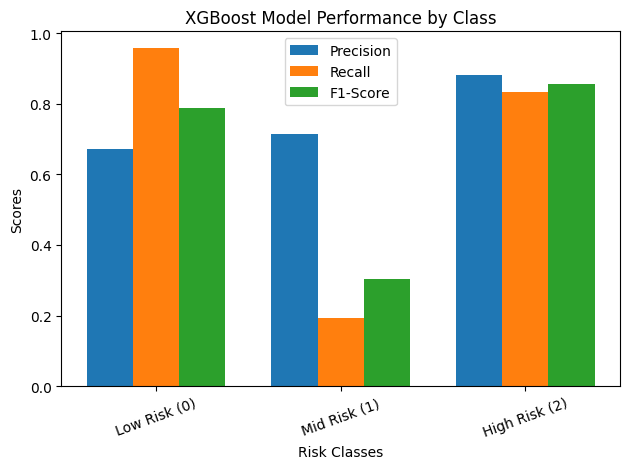

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Get classification report as dictionary
report = classification_report(y_test, xgb_pred, output_dict=True)

# Extract values for each class
labels = ['Low Risk (0)', 'Mid Risk (1)', 'High Risk (2)']

precision = [
    report['0']['precision'],
    report['1']['precision'],
    report['2']['precision']
]

recall = [
    report['0']['recall'],
    report['1']['recall'],
    report['2']['recall']
]

f1_score = [
    report['0']['f1-score'],
    report['1']['f1-score'],
    report['2']['f1-score']
]

# Bar positions
x = np.arange(len(labels))
width = 0.25

# Plot
plt.figure()

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-Score')

# Labels & title
plt.xlabel('Risk Classes')
plt.ylabel('Scores')
plt.title('XGBoost Model Performance by Class')

plt.xticks(x, labels, rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

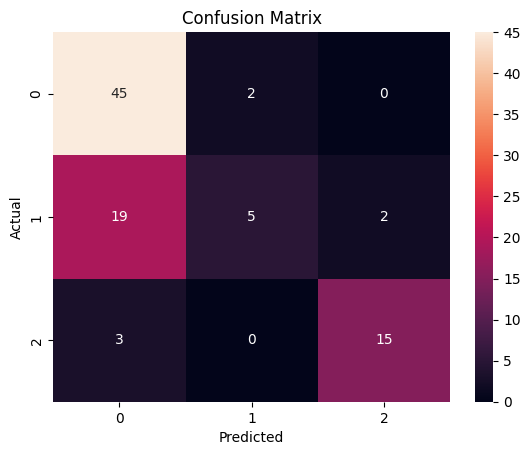

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()